# Project #4 — Model Evaluation and Time-Series Validation

In financial machine learning, the main challenge is often not model selection but **how models are evaluated**.

Traditional machine learning relies on random train-test splits and cross-validation.  
However, financial time series are **temporal, non-stationary, and autocorrelated**, which makes standard validation procedures unreliable.

This notebook demonstrates:

- Why random splits are misleading in finance  
- How proper time-series validation changes model performance  
- Why evaluation methodology matters more than model complexity


##Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit


##Load Data

In [3]:
import yfinance as yf

data = yf.download("SPY", start="2005-01-01", auto_adjust=True, progress=False)

prices = data["Close"]  # Adjusted close when auto_adjust=True
returns = np.log(prices / prices.shift(1)).dropna()


## Feature Engineering and Target Construction


In [4]:
# Create feature DataFrame
features = pd.DataFrame(index=returns.index)

# --- Volatility features ---
features["vol_20"] = returns.rolling(20).std()
features["vol_60"] = returns.rolling(60).std()

# --- Return transformations ---
features["abs_return"] = returns.abs()
features["squared_return"] = returns ** 2

# --- Momentum features ---
features["momentum_5"] = prices.pct_change(5)
features["momentum_20"] = prices.pct_change(20)

# --- Lagged returns ---
for lag in range(1, 6):
    features[f"lag_{lag}"] = returns.shift(lag)

# --- Target: next-day direction (binary classification) ---
target = (returns.shift(-1) > 0).astype(int)

# Combine dataset
dataset = features.copy()
dataset["target"] = target

# Drop missing values created by rolling windows and shifts
dataset = dataset.dropna()

dataset.head()


,vol_20,vol_60,abs_return,squared_return,momentum_5,momentum_20,lag_1,lag_2,lag_3,lag_4,lag_5,target
Date,,,,,,,,,,,,
2005-03-31,0.006813,0.006562,0.001863,0.000003,0.008205,-0.022668,0.014060,-0.006671,0.001450,0.001196,0.000855,0
2005-04-01,0.006842,0.006395,0.004503,0.000020,0.002476,-0.027461,-0.001863,0.014060,-0.006671,0.001450,0.001196,1
2005-04-04,0.006086,0.006336,0.001702,0.000003,0.002728,-0.037790,-0.004503,-0.001863,0.014060,-0.006671,0.001450,1
2005-04-05,0.006247,0.006332,0.004749,0.000023,0.014245,-0.033682,0.001702,-0.004503,-0.001863,0.014060,-0.006671,1
2005-04-06,0.006331,0.006345,0.003463,0.000012,0.003554,-0.026683,0.004749,0.001702,-0.004503,-0.001863,0.014060,1


## Train Features and Target Separation


In [5]:
X = dataset.drop(columns="target")
y = dataset["target"]


## Random Train–Test Split (Incorrect for Time Series)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=True,      # ← PROBLEMA en time series
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_random = accuracy_score(y_test, y_pred)
accuracy_random


0.5377777777777778

## Time-Series Cross-Validation (Correct Evaluation Approach)


In [7]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

accuracies_ts = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies_ts.append(acc)

accuracy_ts_mean = np.mean(accuracies_ts)
accuracy_ts_mean


np.float64(0.5528604118993135)

## Performance Comparison: Random Split vs Time-Series Validation


In [8]:
print("Accuracy (Random Split):", round(accuracy_random, 4))
print("Accuracy (Time-Series CV):", round(accuracy_ts_mean, 4))


Accuracy (Random Split): 0.5378
Accuracy (Time-Series CV): 0.5529


## Time-Series Cross-Validation Performance Visualization


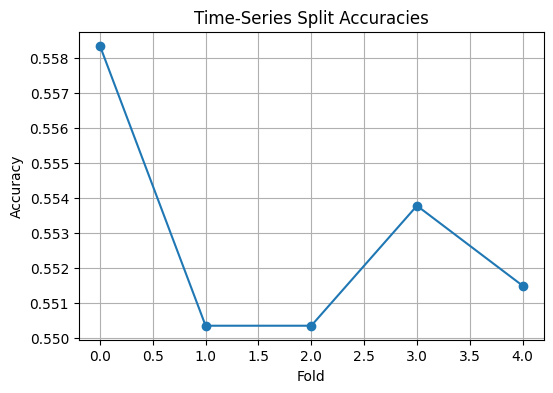

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(accuracies_ts, marker="o")
plt.title("Time-Series Split Accuracies")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## Interpretation

Random train-test splits mix past and future information, producing over-optimistic performance estimates.

Time-series validation respects the chronological structure of financial data and therefore provides a more realistic measure of predictive performance.

This experiment illustrates a central principle of financial machine learning:

> Evaluation methodology matters more than model complexity.


## Key Takeaways

- Random splits are misleading in financial time series  
- Proper temporal validation reduces apparent performance  
- Many ML successes disappear after correct evaluation  
- Robust evaluation is essential before any trading application
